# Language Identification for Very Short Texts

This notebook reconstructs the project step by step in an exploratory format, as if the experiments had first been tested here and only later moved into standalone scripts.

It follows the decisions and structure documented in:
- `.project_meta/PROJECT_TRACKER.md`
- `.project_meta/PROJECT_DOCUMENTATION.md`
- the Python modules inside `src/language_identification`

The notebook mirrors the same logical flow as the final project:
1. the experimental setup;
2. local processed data inspection;
3. reconstruction of length and noise transformations;
4. baseline retraining on the same splits;
5. reevaluation on all conditions;
6. plots, per-language analysis, and error analysis.

## How to Read This Notebook

To keep the notebook reproducible and runnable without network access, it starts from the local artifacts that already exist in the project:
- `data/processed/hq_multilingual/base_dataset.parquet`
- `data/processed/hq_multilingual/processed_dataset.parquet`
- `results/results.csv`
- `results/per_language_results.csv`

That means the original Hugging Face loading step is still respected methodologically, but the executable reconstruction here uses the local processed dataset, which matches the final state of the project.

In [1]:
from __future__ import annotations

import sys
import tempfile
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.metrics import confusion_matrix

NOTEBOOK_OR_CWD = Path.cwd()
PROJECT_ROOT = NOTEBOOK_OR_CWD if (NOTEBOOK_OR_CWD / 'pyproject.toml').exists() else NOTEBOOK_OR_CWD.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from language_identification.data.prepare import (
    LENGTH_BUCKETS,
    NOISE_TYPES,
    TARGET_LANGUAGES,
    apply_single_typo,
    remove_diacritics,
    take_first_n_words,
)
from language_identification.evaluation.baselines import evaluate_model, predict_labels
from language_identification.evaluation.plots import (
    plot_accuracy_by_length,
    plot_accuracy_by_noise,
    plot_accuracy_heatmap_table,
    plot_speed_by_length,
)
from language_identification.models.fasttext_baseline import train_fasttext_model
from language_identification.models.sklearn_baselines import build_model

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

print(f'Project root: {PROJECT_ROOT}')
print(f'Notebook target: {PROJECT_ROOT / "notebooks" / "short_text_language_identification_walkthrough.ipynb"}')

Project root: /home/andrei/Desktop/facultate/BigData/language_identification
Notebook target: /home/andrei/Desktop/facultate/BigData/language_identification/notebooks/short_text_language_identification_walkthrough.ipynb


/home/andrei/Desktop/facultate/BigData/language_identification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Experimental Setup

From the tracker and the documentation, the final setup is stable and clear:
- 5 languages: `EN`, `RO`, `FR`, `DE`, `ES`
- 3 controlled text lengths: `3`, `5`, `10` words
- 3 noise conditions: `clean`, `no_diacritics`, `typo`
- training on `clean` only, separately for each length bucket
- evaluation on `val` and `test` across all 9 scenarios
- 3 baseline models: `tfidf_lr`, `char_svm`, `fasttext`

In [2]:
setup_df = pd.DataFrame(
    [
        ('Target languages', ', '.join(TARGET_LANGUAGES)),
        ('Length buckets', ', '.join(str(x) for x in LENGTH_BUCKETS)),
        ('Noise types', ', '.join(NOISE_TYPES)),
        ('Training policy', 'clean only, one model per length bucket'),
        ('Evaluation policy', 'val and test, same length bucket, all noise conditions'),
        ('Baselines', 'char_svm, tfidf_lr, fasttext'),
    ],
    columns=['component', 'value'],
)
display(setup_df)

,component,value
0,Target languages,"en, ro, fr, de, es"
1,Length buckets,"3, 5, 10"
2,Noise types,"clean, no_diacritics, typo"
3,Training policy,"clean only, one model per length bucket"
4,Evaluation policy,"val and test, same length bucket, all noise conditions"
5,Baselines,"char_svm, tfidf_lr, fasttext"


In [3]:
module_map = pd.DataFrame(
    [
        ('Data preparation', 'src/language_identification/data/prepare.py', 'cleaning, splits, short texts, noise generation'),
        ('Dataset script', 'src/language_identification/scripts/prepare_dataset.py', 'CLI wrapper for dataset preparation'),
        ('Sklearn baselines', 'src/language_identification/models/sklearn_baselines.py', 'tfidf_lr and char_svm builders'),
        ('fastText baseline', 'src/language_identification/models/fasttext_baseline.py', 'fastText training and prediction helpers'),
        ('Training script', 'src/language_identification/scripts/train_baselines.py', 'train all baselines and save the manifest'),
        ('Evaluation core', 'src/language_identification/evaluation/baselines.py', 'shared prediction and metric computation'),
        ('Evaluation script', 'src/language_identification/scripts/evaluate.py', 'global metrics over all conditions'),
        ('Per-language script', 'src/language_identification/scripts/evaluate_per_language.py', 'accuracy broken down by language'),
        ('Plot utilities', 'src/language_identification/evaluation/plots.py', 'accuracy and speed plots'),
        ('Plot script', 'src/language_identification/scripts/plot_results.py', 'write plots to results/plots'),
        ('Final analysis script', 'src/language_identification/scripts/analyze_results.py', 'generate FINAL_ANALYSIS.md'),
        ('Error analysis script', 'src/language_identification/scripts/error_analysis.py', 'hardest-case confusion analysis'),
        ('Train CSV export', 'src/language_identification/scripts/export_train_csv.py', 'readable CSV export for training rows'),
        ('CLI entrypoint', 'src/language_identification/cli.py', 'simple project smoke-test entrypoint'),
    ],
    columns=['project_step', 'file', 'role'],
)
display(module_map)

,project_step,file,role
0,Data preparation,src/language_identification/data/prepare.py,"cleaning, splits, short texts, noise generation"
1,Dataset script,src/language_identification/scripts/prepare_dataset.py,CLI wrapper for dataset preparation
2,Sklearn baselines,src/language_identification/models/sklearn_baselines.py,tfidf_lr and char_svm builders
3,fastText baseline,src/language_identification/models/fasttext_baseline.py,fastText training and prediction helpers
4,Training script,src/language_identification/scripts/train_baselines.py,train all baselines and save the manifest
5,Evaluation core,src/language_identification/evaluation/baselines.py,shared prediction and metric computation
6,Evaluation script,src/language_identification/scripts/evaluate.py,global metrics over all conditions
7,Per-language script,src/language_identification/scripts/evaluate_per_language.py,accuracy broken down by language
8,Plot utilities,src/language_identification/evaluation/plots.py,accuracy and speed plots
9,Plot script,src/language_identification/scripts/plot_results.py,write plots to results/plots


## 2. Loading the Local Artifacts

This section verifies exactly the material used in the final project: the base dataset, the condition-expanded dataset, the train export, the model manifest, and the stored results.

In [4]:
DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'hq_multilingual'
RESULTS_DIR = PROJECT_ROOT / 'results'
BASE_DATASET_PATH = DATA_DIR / 'base_dataset.parquet'
PROCESSED_DATASET_PATH = DATA_DIR / 'processed_dataset.parquet'
SUMMARY_PATH = DATA_DIR / 'dataset_summary.csv'
TRAIN_EXPORT_PATH = DATA_DIR / 'train_clean_all_buckets.csv'
STORED_RESULTS_PATH = RESULTS_DIR / 'results.csv'
STORED_PER_LANGUAGE_PATH = RESULTS_DIR / 'per_language_results.csv'
STORED_MANIFEST_PATH = RESULTS_DIR / 'baselines' / 'model_manifest.csv'
FINAL_ANALYSIS_PATH = RESULTS_DIR / 'FINAL_ANALYSIS.md'

base_df = pd.read_parquet(BASE_DATASET_PATH)
processed_df = pd.read_parquet(PROCESSED_DATASET_PATH)
summary_df = pd.read_csv(SUMMARY_PATH)
train_export_df = pd.read_csv(TRAIN_EXPORT_PATH)
stored_results_df = pd.read_csv(STORED_RESULTS_PATH)
stored_per_language_df = pd.read_csv(STORED_PER_LANGUAGE_PATH)
stored_manifest_df = pd.read_csv(STORED_MANIFEST_PATH)
final_analysis_text = FINAL_ANALYSIS_PATH.read_text(encoding='utf-8')

artifact_df = pd.DataFrame(
    [
        (str(BASE_DATASET_PATH.relative_to(PROJECT_ROOT)), base_df.shape),
        (str(PROCESSED_DATASET_PATH.relative_to(PROJECT_ROOT)), processed_df.shape),
        (str(SUMMARY_PATH.relative_to(PROJECT_ROOT)), summary_df.shape),
        (str(TRAIN_EXPORT_PATH.relative_to(PROJECT_ROOT)), train_export_df.shape),
        (str(STORED_MANIFEST_PATH.relative_to(PROJECT_ROOT)), stored_manifest_df.shape),
        (str(STORED_RESULTS_PATH.relative_to(PROJECT_ROOT)), stored_results_df.shape),
        (str(STORED_PER_LANGUAGE_PATH.relative_to(PROJECT_ROOT)), stored_per_language_df.shape),
    ],
    columns=['artifact', 'shape'],
)
display(artifact_df)

,artifact,shape
0,data/processed/hq_multilingual/base_dataset.parquet,"(10000, 5)"
1,data/processed/hq_multilingual/processed_dataset.parquet,"(90000, 6)"
2,data/processed/hq_multilingual/dataset_summary.csv,"(135, 5)"
3,data/processed/hq_multilingual/train_clean_all_buckets.csv,"(24000, 6)"
4,results/baselines/model_manifest.csv,"(9, 8)"
5,results/results.csv,"(54, 11)"
6,results/per_language_results.csv,"(270, 10)"


In [5]:
display(base_df.head(8))
display(processed_df.head(8))
display(train_export_df.head(8))

,source_id,text,label,word_count,split
0,de_6454,Walter Berschin: Auffällige Formen lateinischer Biographie in Spätantike und Mittelalter .,de,10,train
1,fr_5942,La fin du règne de Louis XIV est marquée par une grande disette touchant l'ensemble de la France en raison d'une période de grand froid .,fr,27,train
2,es_9774,"Escorchado, en el caso de los cuadrúpedos, significa que el animal está desollado, y en el caso de las aves, que está desplumada.",es,23,train
3,de_7674,"Gewinnung und Darstellung Cadmium wird ausschließlich als Nebenprodukt bei der Zinkverhüttung, in kleinem Umfang auch bei der Bleiund Ku...",de,20,train
4,de_6993,Auf den Rechenbrettern des griechisch-römischen Altertums und des christlichen Mittelalters stand für die Darstellung ganzer Zahlen ein ...,de,43,train
5,en_1056,"In the Soviet era, literacy and average education levels rose dramatically from their very low starting point, despite two changes in th...",en,41,train
6,fr_5391,Le linguiste distingue dans le signe deux éléments : le signifié et le signifiant.,fr,13,train
7,fr_5338,"Types Le langage C comprend de nombreux types de nombres entiers, occupant plus ou moins de bits.",fr,17,train


,source_id,split,label,len_bucket,noise_type,text
0,de_6454,train,de,3,clean,Walter Berschin: Auffällige
1,de_6454,train,de,3,no_diacritics,Walter Berschin: Auffallige
2,de_6454,train,de,3,typo,Walter Bersahin: Auffällige
3,de_6454,train,de,5,clean,Walter Berschin: Auffällige Formen lateinischer
4,de_6454,train,de,5,no_diacritics,Walter Berschin: Auffallige Formen lateinischer
5,de_6454,train,de,5,typo,Walter Berschin: Auffällige Formen ljteinischer
6,de_6454,train,de,10,clean,Walter Berschin: Auffällige Formen lateinischer Biographie in Spätantike und Mittelalter
7,de_6454,train,de,10,no_diacritics,Walter Berschin: Auffallige Formen lateinischer Biographie in Spatantike und Mittelalter


,source_id,split,label,len_bucket,noise_type,text
0,de_6000,train,de,3,clean,Mit der Besetzung
1,de_6002,train,de,3,clean,Dies kam in
2,de_6003,train,de,3,clean,Später entstand in
3,de_6004,train,de,3,clean,Der Begriff wurde
4,de_6005,train,de,3,clean,Chr. geschrieben und
5,de_6006,train,de,3,clean,Fragmentarisch erhalten ist
6,de_6007,train,de,3,clean,"Etsch, Po und"
7,de_6009,train,de,3,clean,Im Jahre 1776


## 3. Quick Checks on the Prepared Dataset

According to the documentation, after filtering we should have:
- `2000` examples per language in the final base dataset;
- an `80/10/10` split;
- for each example, an expansion over `3` lengths and `3` noise conditions.

In [6]:
base_counts = (
    base_df.groupby(['label', 'split'])['source_id']
    .count()
    .unstack(fill_value=0)
    .reindex(index=TARGET_LANGUAGES)
)
word_stats = base_df.groupby('label')['word_count'].agg(['min', 'median', 'mean', 'max']).round(2)
processed_counts = (
    processed_df.groupby(['split', 'len_bucket', 'noise_type'])['source_id']
    .count()
    .reset_index(name='n_rows')
    .sort_values(['split', 'len_bucket', 'noise_type'])
)

print('Base dataset rows:', len(base_df))
print('Processed dataset rows:', len(processed_df))
print('Expected processed rows:', len(base_df) * len(LENGTH_BUCKETS) * len(NOISE_TYPES))
print()
display(base_counts)
display(word_stats)
display(processed_counts.head(12))

Base dataset rows: 10000
Processed dataset rows: 90000
Expected processed rows: 90000



split,test,train,val
label,,,
en,200,1600,200
ro,200,1600,200
fr,200,1600,200
de,200,1600,200
es,200,1600,200


,min,median,mean,max
label,,,,
de,10,18.0,20.79,99
en,10,21.0,23.49,163
es,10,25.0,27.35,178
fr,10,24.0,26.95,161
ro,10,22.0,26.84,170


,split,len_bucket,noise_type,n_rows
0,test,3,clean,1000
1,test,3,no_diacritics,1000
2,test,3,typo,1000
3,test,5,clean,1000
4,test,5,no_diacritics,1000
5,test,5,typo,1000
6,test,10,clean,1000
7,test,10,no_diacritics,1000
8,test,10,typo,1000
9,train,3,clean,8000


In [7]:
assert len(base_df) == 10_000
assert len(processed_df) == len(base_df) * len(LENGTH_BUCKETS) * len(NOISE_TYPES)
assert set(base_df['label']) == set(TARGET_LANGUAGES)
assert set(processed_df['noise_type']) == set(NOISE_TYPES)
assert set(processed_df['len_bucket']) == set(LENGTH_BUCKETS)
print('Dataset checks passed.')

Dataset checks passed.


## 4. How Short Texts and Noise Variants Are Built

In `prepare.py`, the rules are intentionally simple and easy to explain:
- keep the first `N` words for the chosen length bucket;
- `no_diacritics` uses `unidecode`;
- `typo` deterministically changes a single character based on `source_id` and the length bucket.

In [8]:
sample_rows = base_df.groupby('label', group_keys=False).head(1).reset_index(drop=True)
demo_rows = []
for row in sample_rows.itertuples(index=False):
    for len_bucket in LENGTH_BUCKETS:
        short_text = take_first_n_words(row.text, len_bucket)
        demo_rows.append(
            {
                'label': row.label,
                'source_id': row.source_id,
                'len_bucket': len_bucket,
                'clean': short_text,
                'no_diacritics': remove_diacritics(short_text),
                'typo': apply_single_typo(short_text, seed_text=f'{row.source_id}:{len_bucket}'),
            }
        )
demo_df = pd.DataFrame(demo_rows)
display(demo_df)

,label,source_id,len_bucket,clean,no_diacritics,typo
0,de,de_6454,3,Walter Berschin: Auffällige,Walter Berschin: Auffallige,Walter Bersahin: Auffällige
1,de,de_6454,5,Walter Berschin: Auffällige Formen lateinischer,Walter Berschin: Auffallige Formen lateinischer,Walter Berschin: Auffällige Formen ljteinischer
2,de,de_6454,10,Walter Berschin: Auffällige Formen lateinischer Biographie in Spätantike und Mittelalter,Walter Berschin: Auffallige Formen lateinischer Biographie in Spatantike und Mittelalter,Walter Berschin: Auffällige Formen lateinischer Biographie in Spätanqike und Mittelalter
3,fr,fr_5942,3,La fin du,La fin du,La fen du
4,fr,fr_5942,5,La fin du règne de,La fin du regne de,La fin du rtgne de
5,fr,fr_5942,10,La fin du règne de Louis XIV est marquée par,La fin du regne de Louis XIV est marquee par,La fin du règne de Louis YIV est marquée par
6,es,es_9774,3,"Escorchado, en el","Escorchado, en el","Escorchtdo, en el"
7,es,es_9774,5,"Escorchado, en el caso de","Escorchado, en el caso de","Escorceado, en el caso de"
8,es,es_9774,10,"Escorchado, en el caso de los cuadrúpedos, significa que el","Escorchado, en el caso de los cuadrupedos, significa que el","Escodchado, en el caso de los cuadrúpedos, significa que el"
9,en,en_1056,3,In the Soviet,In the Soviet,In the Seviet


In [9]:
check_source_id = sample_rows.iloc[0]['source_id']
reconstructed_rows = []
original_text = sample_rows.iloc[0]['text']
for len_bucket in LENGTH_BUCKETS:
    short_text = take_first_n_words(original_text, len_bucket)
    for noise_type in NOISE_TYPES:
        if noise_type == 'clean':
            transformed = short_text
        elif noise_type == 'no_diacritics':
            transformed = remove_diacritics(short_text)
        else:
            transformed = apply_single_typo(short_text, seed_text=f'{check_source_id}:{len_bucket}')
        reconstructed_rows.append(
            {
                'source_id': check_source_id,
                'len_bucket': len_bucket,
                'noise_type': noise_type,
                'reconstructed_text': transformed,
            }
        )

reconstructed_df = pd.DataFrame(reconstructed_rows)
stored_rows = processed_df[processed_df['source_id'] == check_source_id][['source_id', 'len_bucket', 'noise_type', 'text']].rename(columns={'text': 'stored_text'})
consistency_check = reconstructed_df.merge(stored_rows, on=['source_id', 'len_bucket', 'noise_type'])
consistency_check['matches_processed_dataset'] = consistency_check['reconstructed_text'] == consistency_check['stored_text']
display(consistency_check)
assert consistency_check['matches_processed_dataset'].all()
print('The local processed dataset matches the transformation functions.')

,source_id,len_bucket,noise_type,reconstructed_text,stored_text,matches_processed_dataset
0,de_6454,3,clean,Walter Berschin: Auffällige,Walter Berschin: Auffällige,True
1,de_6454,3,no_diacritics,Walter Berschin: Auffallige,Walter Berschin: Auffallige,True
2,de_6454,3,typo,Walter Bersahin: Auffällige,Walter Bersahin: Auffällige,True
3,de_6454,5,clean,Walter Berschin: Auffällige Formen lateinischer,Walter Berschin: Auffällige Formen lateinischer,True
4,de_6454,5,no_diacritics,Walter Berschin: Auffallige Formen lateinischer,Walter Berschin: Auffallige Formen lateinischer,True
5,de_6454,5,typo,Walter Berschin: Auffällige Formen ljteinischer,Walter Berschin: Auffällige Formen ljteinischer,True
6,de_6454,10,clean,Walter Berschin: Auffällige Formen lateinischer Biographie in Spätantike und Mittelalter,Walter Berschin: Auffällige Formen lateinischer Biographie in Spätantike und Mittelalter,True
7,de_6454,10,no_diacritics,Walter Berschin: Auffallige Formen lateinischer Biographie in Spatantike und Mittelalter,Walter Berschin: Auffallige Formen lateinischer Biographie in Spatantike und Mittelalter,True
8,de_6454,10,typo,Walter Berschin: Auffällige Formen lateinischer Biographie in Spätanqike und Mittelalter,Walter Berschin: Auffällige Formen lateinischer Biographie in Spätanqike und Mittelalter,True


The local processed dataset matches the transformation functions.


## 5. Retraining the Baselines in Notebook Form

This recreates the part that eventually became `train_baselines.py`. To avoid leaving extra artifacts in the repository, the notebook stores its retrained models inside a temporary directory.

In [10]:
TMP_MODELS = tempfile.TemporaryDirectory(prefix='lid_notebook_models_')
TEMP_ROOT = Path(TMP_MODELS.name)
TEMP_MODELS_DIR = TEMP_ROOT / 'models'
TEMP_MODELS_DIR.mkdir(parents=True, exist_ok=True)

train_clean_df = processed_df[(processed_df['split'] == 'train') & (processed_df['noise_type'] == 'clean')].copy()
model_names = ['char_svm', 'tfidf_lr', 'fasttext']
notebook_manifest_rows = []

for model_name in model_names:
    for len_bucket in LENGTH_BUCKETS:
        bucket_train_df = train_clean_df[train_clean_df['len_bucket'] == len_bucket].copy()
        start = time.perf_counter()
        if model_name == 'fasttext':
            model_backend = 'fasttext'
            model_path = TEMP_MODELS_DIR / f'{model_name}_len{len_bucket}.bin'
            training_file_size_mb = train_fasttext_model(bucket_train_df, model_path)
            train_runtime_sec = time.perf_counter() - start
        else:
            model_backend = 'sklearn'
            model = build_model(model_name)
            model.fit(bucket_train_df['text'].tolist(), bucket_train_df['label'].tolist())
            train_runtime_sec = time.perf_counter() - start
            model_path = TEMP_MODELS_DIR / f'{model_name}_len{len_bucket}.joblib'
            joblib.dump(model, model_path)
            training_file_size_mb = None

        notebook_manifest_rows.append(
            {
                'model': model_name,
                'model_backend': model_backend,
                'train_len_bucket': len_bucket,
                'train_noise_type': 'clean',
                'n_train_examples': len(bucket_train_df),
                'train_runtime_sec': train_runtime_sec,
                'training_file_size_mb': training_file_size_mb,
                'model_path': str(model_path),
            }
        )

notebook_manifest_df = pd.DataFrame(notebook_manifest_rows).sort_values(['model', 'train_len_bucket']).reset_index(drop=True)
display(notebook_manifest_df)

Read 0M words
Number of words:  11761
Number of labels: 5


Progress: 100.0% words/sec/thread: 1167292 lr:  0.000000 avg.loss:  0.051559 ETA:   0h 0m 0s
Read 0M words
Number of words:  17862
Number of labels: 5


Progress: 100.0% words/sec/thread:  971522 lr:  0.000000 avg.loss:  0.045771 ETA:   0h 0m 0s
Read 0M words
Number of words:  31035
Number of labels: 5


Progress: 100.0% words/sec/thread:  855703 lr:  0.000000 avg.loss:  0.041373 ETA:   0h 0m 0s


,model,model_backend,train_len_bucket,train_noise_type,n_train_examples,train_runtime_sec,training_file_size_mb,model_path
0,char_svm,sklearn,3,clean,8000,0.261133,NaN,/tmp/lid_notebook_models_mlw3hd70/models/char_svm_len3.joblib
1,char_svm,sklearn,5,clean,8000,0.461483,NaN,/tmp/lid_notebook_models_mlw3hd70/models/char_svm_len5.joblib
2,char_svm,sklearn,10,clean,8000,0.716201,NaN,/tmp/lid_notebook_models_mlw3hd70/models/char_svm_len10.joblib
3,fasttext,fasttext,3,clean,8000,1.451628,0.245412,/tmp/lid_notebook_models_mlw3hd70/models/fasttext_len3.bin
4,fasttext,fasttext,5,clean,8000,2.039627,0.346601,/tmp/lid_notebook_models_mlw3hd70/models/fasttext_len5.bin
5,fasttext,fasttext,10,clean,8000,3.410699,0.600496,/tmp/lid_notebook_models_mlw3hd70/models/fasttext_len10.bin
6,tfidf_lr,sklearn,3,clean,8000,8.311497,NaN,/tmp/lid_notebook_models_mlw3hd70/models/tfidf_lr_len3.joblib
7,tfidf_lr,sklearn,5,clean,8000,7.742807,NaN,/tmp/lid_notebook_models_mlw3hd70/models/tfidf_lr_len5.joblib
8,tfidf_lr,sklearn,10,clean,8000,4.561161,NaN,/tmp/lid_notebook_models_mlw3hd70/models/tfidf_lr_len10.joblib


In [11]:
manifest_compare = stored_manifest_df.merge(
    notebook_manifest_df,
    on=['model', 'model_backend', 'train_len_bucket', 'train_noise_type', 'n_train_examples'],
    suffixes=('_stored', '_notebook'),
)
manifest_compare['train_runtime_ratio_notebook_vs_stored'] = (
    manifest_compare['train_runtime_sec_notebook'] / manifest_compare['train_runtime_sec_stored']
).round(3)

display(
    manifest_compare[
        [
            'model',
            'train_len_bucket',
            'n_train_examples',
            'train_runtime_sec_stored',
            'train_runtime_sec_notebook',
            'train_runtime_ratio_notebook_vs_stored',
        ]
    ]
)

,model,train_len_bucket,n_train_examples,train_runtime_sec_stored,train_runtime_sec_notebook,train_runtime_ratio_notebook_vs_stored
0,char_svm,3,8000,0.310848,0.261133,0.840
1,char_svm,5,8000,0.496936,0.461483,0.929
2,char_svm,10,8000,1.012309,0.716201,0.707
3,tfidf_lr,3,8000,13.721109,8.311497,0.606
4,tfidf_lr,5,8000,10.801843,7.742807,0.717
5,tfidf_lr,10,8000,7.798865,4.561161,0.585
6,fasttext,3,8000,1.856129,1.451628,0.782
7,fasttext,5,8000,2.533580,2.039627,0.805
8,fasttext,10,8000,4.206584,3.410699,0.811


## 6. Evaluation on `val` and `test` Across All 9 Conditions

We now recreate the logic from `evaluate.py`: for each model and each length bucket, we evaluate on `clean`, `no_diacritics`, and `typo`.

In [12]:
notebook_results_rows = []
for item in notebook_manifest_df.itertuples(index=False):
    for split in ['val', 'test']:
        for noise_type in NOISE_TYPES:
            eval_df = processed_df[
                (processed_df['split'] == split)
                & (processed_df['len_bucket'] == item.train_len_bucket)
                & (processed_df['noise_type'] == noise_type)
            ].copy()
            notebook_results_rows.append(
                evaluate_model(
                    model_path=Path(item.model_path),
                    model_name=item.model,
                    model_backend=item.model_backend,
                    train_len_bucket=int(item.train_len_bucket),
                    split=split,
                    noise_type=noise_type,
                    eval_df=eval_df,
                )
            )

notebook_results_df = pd.DataFrame(notebook_results_rows).sort_values(
    ['model', 'split', 'train_len_bucket', 'noise_type']
).reset_index(drop=True)
display(notebook_results_df.head(12))
print('Notebook results shape:', notebook_results_df.shape)

,model,model_backend,train_len_bucket,eval_len_bucket,split,noise_type,n_examples,accuracy,macro_f1,runtime_sec,examples_per_sec
0,char_svm,sklearn,3,3,test,clean,1000,0.927,0.926864,0.012834,77919.365922
1,char_svm,sklearn,3,3,test,no_diacritics,1000,0.899,0.898775,0.012607,79319.307089
2,char_svm,sklearn,3,3,test,typo,1000,0.908,0.908067,0.012881,77633.525198
3,char_svm,sklearn,5,5,test,clean,1000,0.982,0.982009,0.022473,44497.556728
4,char_svm,sklearn,5,5,test,no_diacritics,1000,0.973,0.972989,0.022248,44948.096860
5,char_svm,sklearn,5,5,test,typo,1000,0.972,0.972005,0.022227,44990.576049
6,char_svm,sklearn,10,10,test,clean,1000,0.994,0.994005,0.049826,20070.014245
7,char_svm,sklearn,10,10,test,no_diacritics,1000,0.993,0.993002,0.049706,20118.432383
8,char_svm,sklearn,10,10,test,typo,1000,0.993,0.993002,0.050829,19673.990178
9,char_svm,sklearn,3,3,val,clean,1000,0.947,0.947049,0.012903,77503.050135


Notebook results shape: (54, 11)


In [13]:
comparison_keys = [
    'model',
    'model_backend',
    'train_len_bucket',
    'eval_len_bucket',
    'split',
    'noise_type',
    'n_examples',
]
results_compare = stored_results_df.merge(
    notebook_results_df,
    on=comparison_keys,
    suffixes=('_stored', '_notebook'),
)
for metric in ['accuracy', 'macro_f1', 'runtime_sec', 'examples_per_sec']:
    results_compare[f'{metric}_delta'] = results_compare[f'{metric}_notebook'] - results_compare[f'{metric}_stored']

metric_delta_summary = pd.DataFrame(
    {
        'metric': ['accuracy', 'macro_f1', 'runtime_sec', 'examples_per_sec'],
        'max_abs_delta': [
            results_compare['accuracy_delta'].abs().max(),
            results_compare['macro_f1_delta'].abs().max(),
            results_compare['runtime_sec_delta'].abs().max(),
            results_compare['examples_per_sec_delta'].abs().max(),
        ],
    }
)

display(metric_delta_summary)
display(
    results_compare[
        comparison_keys + [
            'accuracy_stored', 'accuracy_notebook', 'accuracy_delta',
            'macro_f1_stored', 'macro_f1_notebook', 'macro_f1_delta',
        ]
    ].head(12)
)

,metric,max_abs_delta
0,accuracy,0.000000e+00
1,macro_f1,1.110223e-16
2,runtime_sec,1.580955e-02
3,examples_per_sec,1.268882e+05


,model,model_backend,train_len_bucket,eval_len_bucket,split,noise_type,n_examples,accuracy_stored,accuracy_notebook,accuracy_delta,macro_f1_stored,macro_f1_notebook,macro_f1_delta
0,char_svm,sklearn,3,3,test,clean,1000,0.927,0.927,0.0,0.926864,0.926864,1.110223e-16
1,char_svm,sklearn,3,3,test,no_diacritics,1000,0.899,0.899,0.0,0.898775,0.898775,0.000000e+00
2,char_svm,sklearn,3,3,test,typo,1000,0.908,0.908,0.0,0.908067,0.908067,0.000000e+00
3,char_svm,sklearn,5,5,test,clean,1000,0.982,0.982,0.0,0.982009,0.982009,1.110223e-16
4,char_svm,sklearn,5,5,test,no_diacritics,1000,0.973,0.973,0.0,0.972989,0.972989,1.110223e-16
5,char_svm,sklearn,5,5,test,typo,1000,0.972,0.972,0.0,0.972005,0.972005,0.000000e+00
6,char_svm,sklearn,10,10,test,clean,1000,0.994,0.994,0.0,0.994005,0.994005,1.110223e-16
7,char_svm,sklearn,10,10,test,no_diacritics,1000,0.993,0.993,0.0,0.993002,0.993002,0.000000e+00
8,char_svm,sklearn,10,10,test,typo,1000,0.993,0.993,0.0,0.993002,0.993002,0.000000e+00
9,char_svm,sklearn,3,3,val,clean,1000,0.947,0.947,0.0,0.947049,0.947049,0.000000e+00


In [14]:
notebook_test_summary = (
    notebook_results_df[notebook_results_df['split'] == 'test']
    .groupby('model', as_index=False)[['accuracy', 'macro_f1', 'examples_per_sec']]
    .mean()
    .sort_values('accuracy', ascending=False)
    .round(4)
)

best_by_condition = (
    notebook_results_df[notebook_results_df['split'] == 'test']
    .sort_values(['eval_len_bucket', 'noise_type', 'accuracy'], ascending=[True, True, False])
    .groupby(['eval_len_bucket', 'noise_type'], as_index=False)
    .head(1)
    [['eval_len_bucket', 'noise_type', 'model', 'accuracy', 'macro_f1', 'examples_per_sec']]
    .reset_index(drop=True)
)

worst_cases = (
    notebook_results_df[notebook_results_df['split'] == 'test']
    .sort_values('accuracy')
    [['model', 'train_len_bucket', 'noise_type', 'accuracy', 'macro_f1']]
    .head(10)
)

display(notebook_test_summary)
display(best_by_condition)
display(worst_cases)

,model,accuracy,macro_f1,examples_per_sec
0,char_svm,0.9601,0.9601,47685.6516
1,fasttext,0.9553,0.9554,111979.4538
2,tfidf_lr,0.9058,0.9083,264418.3342


,eval_len_bucket,noise_type,model,accuracy,macro_f1,examples_per_sec
0,3,clean,fasttext,0.934,0.934195,167267.827248
1,3,no_diacritics,fasttext,0.911,0.911246,162203.002249
2,3,typo,fasttext,0.909,0.909264,145953.909506
3,5,clean,char_svm,0.982,0.982009,44497.556728
4,5,no_diacritics,char_svm,0.973,0.972989,44948.096860
5,5,typo,char_svm,0.972,0.972005,44990.576049
6,10,clean,char_svm,0.994,0.994005,20070.014245
7,10,no_diacritics,char_svm,0.993,0.993002,20118.432383
8,10,typo,char_svm,0.993,0.993002,19673.990178


,model,train_len_bucket,noise_type,accuracy,macro_f1
38,tfidf_lr,3,typo,0.758,0.768933
37,tfidf_lr,3,no_diacritics,0.818,0.823292
36,tfidf_lr,3,clean,0.846,0.850447
1,char_svm,3,no_diacritics,0.899,0.898775
41,tfidf_lr,5,typo,0.907,0.908311
2,char_svm,3,typo,0.908,0.908067
20,fasttext,3,typo,0.909,0.909264
19,fasttext,3,no_diacritics,0.911,0.911246
40,tfidf_lr,5,no_diacritics,0.921,0.921214
0,char_svm,3,clean,0.927,0.926864


## 7. Main Plots

In the final project, these figures are generated by `plot_results.py`. Here we recreate them from the notebook results and display them inline.

**accuracy_by_length_clean.png**

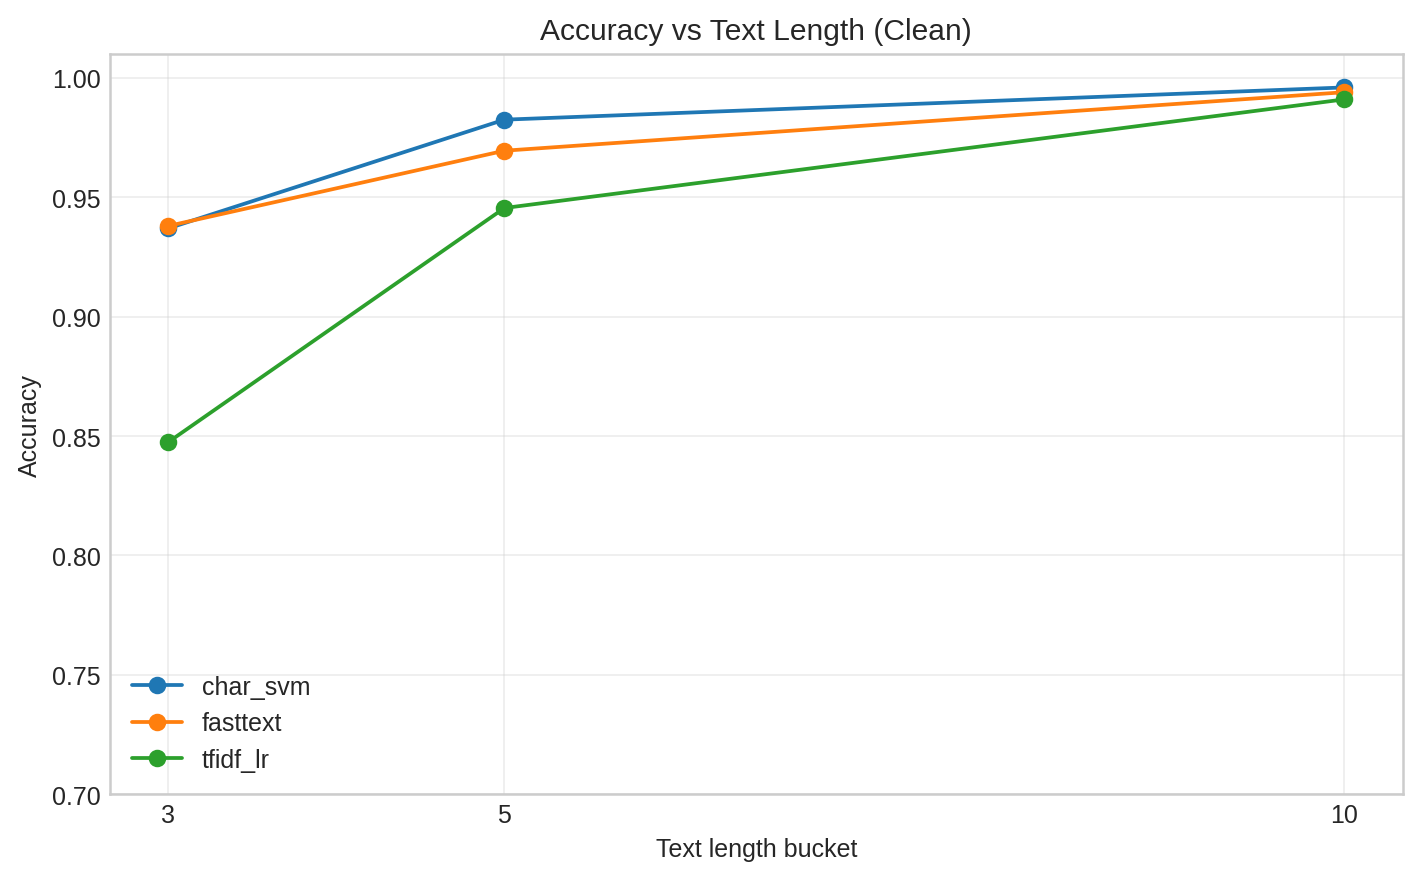

**accuracy_by_noise.png**

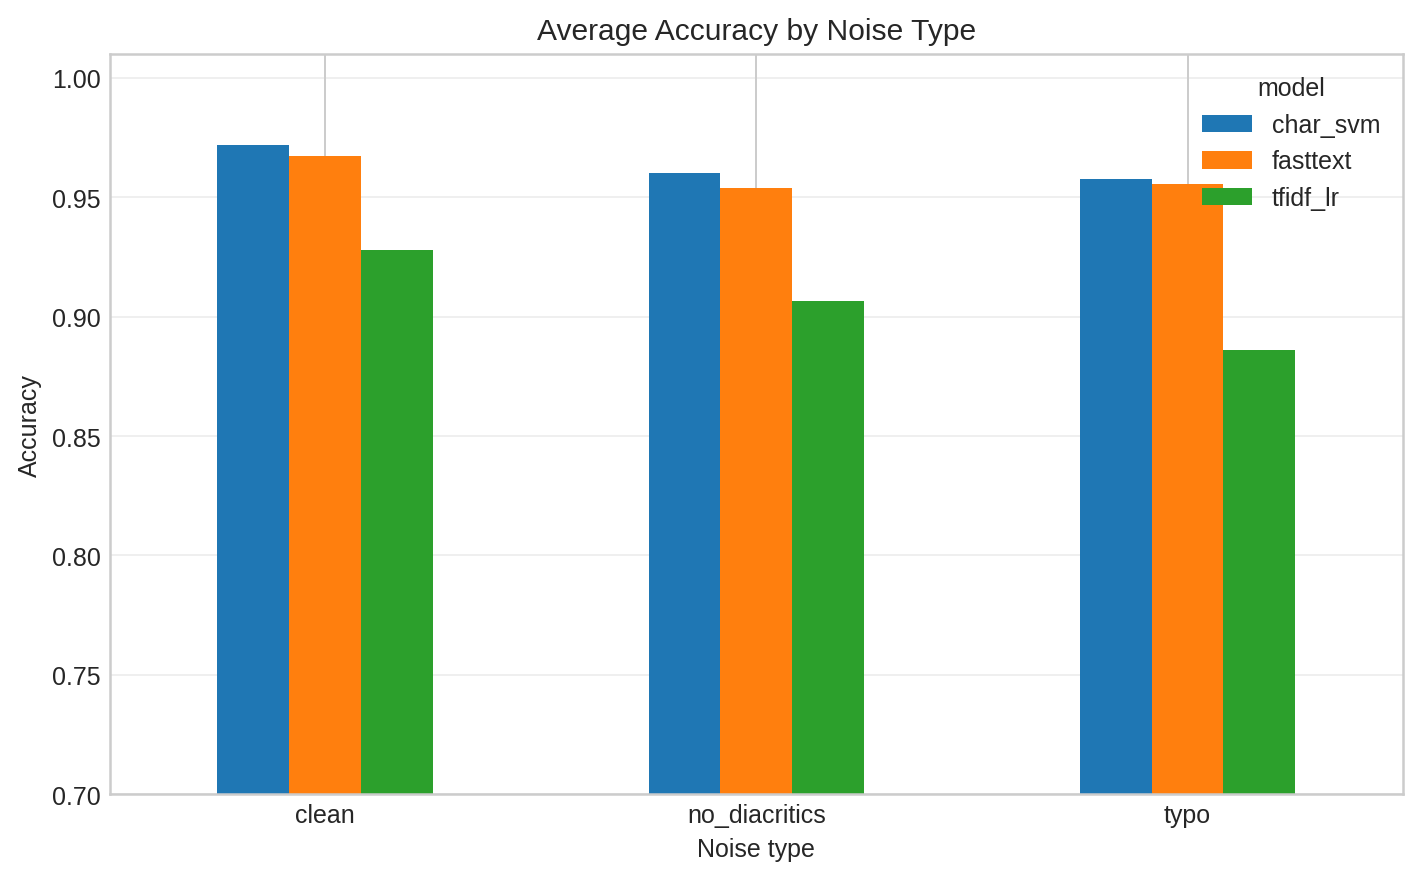

**speed_by_length.png**

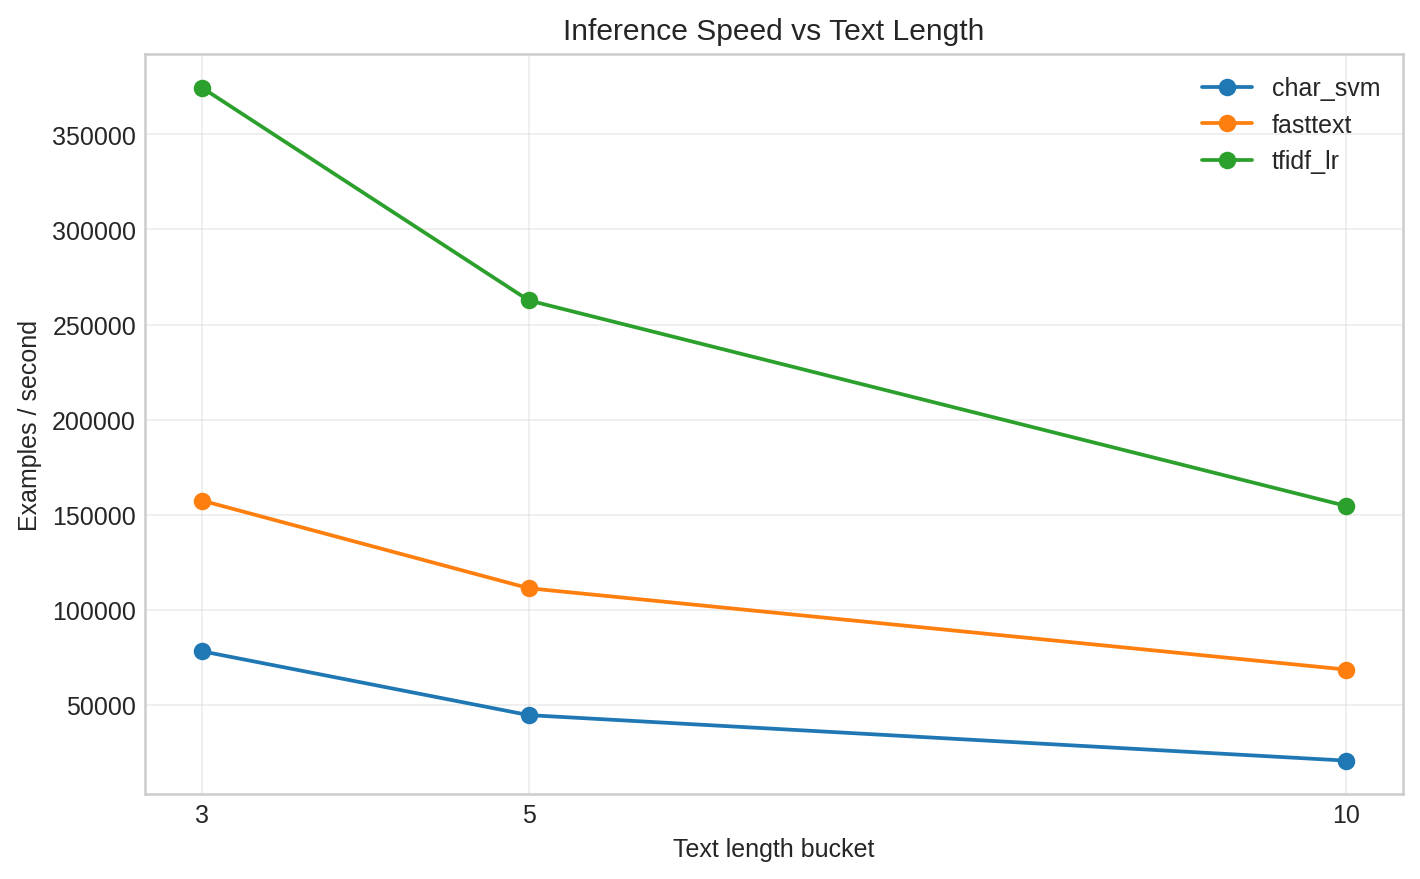

,model,eval_len_bucket,noise_type,accuracy
0,char_svm,3,clean,0.9370
1,char_svm,3,no_diacritics,0.9115
2,char_svm,3,typo,0.9070
3,char_svm,5,clean,0.9825
4,char_svm,5,no_diacritics,0.9735
5,char_svm,5,typo,0.9710
6,char_svm,10,clean,0.9960
7,char_svm,10,no_diacritics,0.9955
8,char_svm,10,typo,0.9950
9,fasttext,3,clean,0.9380


In [15]:
TEMP_PLOTS_DIR = TEMP_ROOT / 'plots'
TEMP_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plot_accuracy_by_length(notebook_results_df, TEMP_PLOTS_DIR)
plot_accuracy_by_noise(notebook_results_df, TEMP_PLOTS_DIR)
plot_speed_by_length(notebook_results_df, TEMP_PLOTS_DIR)
plot_accuracy_heatmap_table(notebook_results_df, TEMP_PLOTS_DIR)

for plot_name in ['accuracy_by_length_clean.png', 'accuracy_by_noise.png', 'speed_by_length.png']:
    display(Markdown(f'**{plot_name}**'))
    display(Image(filename=str(TEMP_PLOTS_DIR / plot_name), width=760))

accuracy_summary_df = pd.read_csv(TEMP_PLOTS_DIR / 'accuracy_summary.csv')
display(accuracy_summary_df.head(12))

## 8. Per-Language Evaluation

This recreates the idea behind `evaluate_per_language.py`, so we can see more clearly which languages are easier and which are harder.

In [16]:
notebook_per_language_rows = []
for item in notebook_manifest_df.itertuples(index=False):
    for split in ['val', 'test']:
        for noise_type in NOISE_TYPES:
            eval_df = processed_df[
                (processed_df['split'] == split)
                & (processed_df['len_bucket'] == item.train_len_bucket)
                & (processed_df['noise_type'] == noise_type)
            ].copy()
            predictions, runtime_sec = predict_labels(
                model_path=Path(item.model_path),
                model_backend=item.model_backend,
                texts=eval_df['text'].tolist(),
            )
            eval_df['predicted_label'] = predictions
            for language, group in eval_df.groupby('label'):
                notebook_per_language_rows.append(
                    {
                        'model': item.model,
                        'model_backend': item.model_backend,
                        'train_len_bucket': int(item.train_len_bucket),
                        'eval_len_bucket': int(item.train_len_bucket),
                        'split': split,
                        'noise_type': noise_type,
                        'language': language,
                        'n_examples': len(group),
                        'accuracy': (group['label'] == group['predicted_label']).mean(),
                        'runtime_sec_total_batch': runtime_sec,
                    }
                )

notebook_per_language_df = pd.DataFrame(notebook_per_language_rows).sort_values(
    ['model', 'split', 'train_len_bucket', 'noise_type', 'language']
).reset_index(drop=True)
display(notebook_per_language_df.head(15))

,model,model_backend,train_len_bucket,eval_len_bucket,split,noise_type,language,n_examples,accuracy,runtime_sec_total_batch
0,char_svm,sklearn,3,3,test,clean,de,200,0.960,0.014959
1,char_svm,sklearn,3,3,test,clean,en,200,0.880,0.014959
2,char_svm,sklearn,3,3,test,clean,es,200,0.950,0.014959
3,char_svm,sklearn,3,3,test,clean,fr,200,0.905,0.014959
4,char_svm,sklearn,3,3,test,clean,ro,200,0.940,0.014959
5,char_svm,sklearn,3,3,test,no_diacritics,de,200,0.960,0.013642
6,char_svm,sklearn,3,3,test,no_diacritics,en,200,0.870,0.013642
7,char_svm,sklearn,3,3,test,no_diacritics,es,200,0.910,0.013642
8,char_svm,sklearn,3,3,test,no_diacritics,fr,200,0.865,0.013642
9,char_svm,sklearn,3,3,test,no_diacritics,ro,200,0.890,0.013642


In [17]:
per_language_compare = stored_per_language_df.merge(
    notebook_per_language_df,
    on=['model', 'model_backend', 'train_len_bucket', 'eval_len_bucket', 'split', 'noise_type', 'language', 'n_examples'],
    suffixes=('_stored', '_notebook'),
)
per_language_compare['accuracy_delta'] = (
    per_language_compare['accuracy_notebook'] - per_language_compare['accuracy_stored']
)
print('Max absolute per-language accuracy delta:', per_language_compare['accuracy_delta'].abs().max())

test_language_summary = (
    notebook_per_language_df[notebook_per_language_df['split'] == 'test']
    .groupby('language', as_index=False)['accuracy']
    .mean()
    .sort_values('accuracy')
    .round(4)
)

hard_case_language_view = (
    notebook_per_language_df[
        (notebook_per_language_df['split'] == 'test')
        & (notebook_per_language_df['train_len_bucket'] == 3)
        & (notebook_per_language_df['noise_type'] == 'typo')
    ]
    .pivot(index='language', columns='model', values='accuracy')
    .round(3)
)

display(test_language_summary)
display(hard_case_language_view)

Max absolute per-language accuracy delta: 0.0


,language,accuracy
3,fr,0.9196
1,en,0.9365
2,es,0.9365
4,ro,0.9515
0,de,0.9580


model,char_svm,fasttext,tfidf_lr
language,,,
de,0.935,0.920,0.750
en,0.880,0.895,0.730
es,0.915,0.890,0.745
fr,0.885,0.915,0.660
ro,0.925,0.925,0.905


## 9. Error Analysis for the Hardest Scenario

According to the final project, the selected hard-case error analysis scenario is:
- model `fasttext`
- `3` words
- `typo` noise
- `test` split

We now rebuild the same analysis directly inside the notebook.

In [18]:
selected_model_row = notebook_manifest_df[
    (notebook_manifest_df['model'] == 'fasttext')
    & (notebook_manifest_df['train_len_bucket'] == 3)
].iloc[0]

hard_eval_df = processed_df[
    (processed_df['split'] == 'test')
    & (processed_df['len_bucket'] == 3)
    & (processed_df['noise_type'] == 'typo')
].copy()

hard_predictions, hard_runtime = predict_labels(
    model_path=Path(selected_model_row['model_path']),
    model_backend=selected_model_row['model_backend'],
    texts=hard_eval_df['text'].tolist(),
)

hard_eval_df['predicted_label'] = hard_predictions
hard_eval_df['is_correct'] = hard_eval_df['label'] == hard_eval_df['predicted_label']
labels = sorted(hard_eval_df['label'].unique())
cm = confusion_matrix(hard_eval_df['label'], hard_eval_df['predicted_label'], labels=labels, normalize='true')
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

off_diag = cm_df.copy()
for label in labels:
    off_diag.loc[label, label] = 0.0

top_confusions_df = (
    off_diag.stack()
    .reset_index()
    .rename(columns={'level_0': 'true_label', 'level_1': 'predicted_label', 0: 'rate'})
    .sort_values('rate', ascending=False)
)
top_confusions_df = top_confusions_df[top_confusions_df['rate'] > 0].reset_index(drop=True)

mistakes_df = hard_eval_df.loc[
    ~hard_eval_df['is_correct'],
    ['source_id', 'label', 'predicted_label', 'text']
].head(12)

display(cm_df.round(3))
display(top_confusions_df.head(12))
display(mistakes_df)
print(f'Runtime for the hardest-case batch: {hard_runtime:.6f}s for {len(hard_eval_df)} examples')

,de,en,es,fr,ro
de,0.920,0.050,0.005,0.010,0.015
en,0.020,0.895,0.015,0.045,0.025
es,0.010,0.020,0.890,0.040,0.040
fr,0.015,0.050,0.015,0.915,0.005
ro,0.000,0.025,0.025,0.025,0.925


,true_label,predicted_label,rate
0,de,en,0.050
1,fr,en,0.050
2,en,fr,0.045
3,es,fr,0.040
4,es,ro,0.040
5,en,ro,0.025
6,ro,es,0.025
7,ro,en,0.025
8,ro,fr,0.025
9,en,de,0.020


,source_id,label,predicted_label,text
81002,ro_3828,ro,fr,Ce pmate face
81038,fr_5343,fr,en,"Ei 1811, Amedeo"
81191,es_9349,es,ro,Ojoi de gato:
81227,en_1088,en,de,When Laiguages Die:
81299,en_300,en,ro,Reita Faria il
81380,ro_2953,ro,en,Ahmed El-Seuussi Ahmed
81479,en_427,en,fr,"Attila , frequentny"
81506,fr_4962,fr,es,Rio Ninto et
81749,es_9927,es,de,Vidrieras Ex arte
81866,en_132,en,fr,Cours d'Analyse Ii


Runtime for the hardest-case batch: 0.006671s for 1000 examples


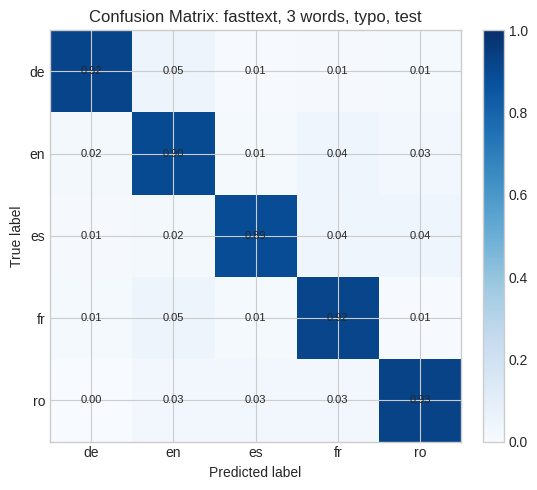

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm_df.values, cmap='Blues', vmin=0.0, vmax=1.0)
ax.set_xticks(range(len(cm_df.columns)))
ax.set_yticks(range(len(cm_df.index)))
ax.set_xticklabels(cm_df.columns)
ax.set_yticklabels(cm_df.index)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix: fasttext, 3 words, typo, test')

for i in range(len(cm_df.index)):
    for j in range(len(cm_df.columns)):
        ax.text(j, i, f'{cm_df.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 10. Final Conclusions of the Reconstruction

The last step is to summarize what the notebook shows and verify that the message stays aligned with `results/FINAL_ANALYSIS.md`.

In [20]:
best_overall_model = notebook_test_summary.iloc[0]
fastest_model = notebook_test_summary.sort_values('examples_per_sec', ascending=False).iloc[0]
hardest_language = test_language_summary.iloc[0]
easiest_language = test_language_summary.iloc[-1]
best_3_words = best_by_condition[best_by_condition['eval_len_bucket'] == 3]
best_10_words = best_by_condition[best_by_condition['eval_len_bucket'] == 10]

conclusion_md = f"""
### Short Takeaways

- On average test performance, **{best_overall_model['model']}** is the strongest overall model, with a mean accuracy of **{best_overall_model['accuracy']:.4f}**.
- In terms of inference speed, **{fastest_model['model']}** remains the fastest, with roughly **{fastest_model['examples_per_sec']:.1f}** examples per second.
- At **3 words**, the practical winner stays **{best_3_words.iloc[0]['model']}**, which confirms that the shortest-text setting is the most fragile one.
- At **10 words**, the lead shifts to **{best_10_words.iloc[0]['model']}**, with accuracy values very close to the ceiling.
- The language with the lowest mean test accuracy in this reconstruction is **{hardest_language['language']}** ({hardest_language['accuracy']:.4f}), while the easiest is **{easiest_language['language']}** ({easiest_language['accuracy']:.4f}).
- The top confusions in the hard-case scenario suggest that most errors happen either between relatively close languages or in fragments that are simply too short to provide a strong lexical signal.

### Connection to the Final Project

The conclusions reached here point in the same direction as `results/FINAL_ANALYSIS.md`:
- performance drops clearly on very short text;
- `char_svm` and `fasttext` are much more robust than `tfidf_lr`;
- `tfidf_lr` compensates with very strong inference speed;
- for short and noisy language identification, character-based and subword-aware models remain the most convincing baselines in this project.
"""
display(Markdown(conclusion_md))


### Short Takeaways

- On average test performance, **char_svm** is the strongest overall model, with a mean accuracy of **0.9601**.
- In terms of inference speed, **tfidf_lr** remains the fastest, with roughly **264418.3** examples per second.
- At **3 words**, the practical winner stays **fasttext**, which confirms that the shortest-text setting is the most fragile one.
- At **10 words**, the lead shifts to **char_svm**, with accuracy values very close to the ceiling.
- The language with the lowest mean test accuracy in this reconstruction is **fr** (0.9196), while the easiest is **de** (0.9580).
- The top confusions in the hard-case scenario suggest that most errors happen either between relatively close languages or in fragments that are simply too short to provide a strong lexical signal.

### Connection to the Final Project

The conclusions reached here point in the same direction as `results/FINAL_ANALYSIS.md`:
- performance drops clearly on very short text;
- `char_svm` and `fasttext` are much more robust than `tfidf_lr`;
- `tfidf_lr` compensates with very strong inference speed;
- for short and noisy language identification, character-based and subword-aware models remain the most convincing baselines in this project.


In [21]:
print(final_analysis_text[:1200])

# Final Analysis

## Summary

This file summarizes the experimental results for language identification on very short texts.

## Average Test Performance

| model | accuracy | macro_f1 | examples_per_sec |
| --- | --- | --- | --- |
| char_svm | 0.9601 | 0.9601 | 38644.7738 |
| fasttext | 0.9553 | 0.9554 | 99264.0637 |
| tfidf_lr | 0.9058 | 0.9083 | 224343.8572 |

## Main Findings

- Performance improves clearly when moving from `3` to `5` and then to `10` words.
- Noise affects the `3`-word setting the most.
- `char_svm` and `fasttext` are much more robust than `tfidf_lr` on very short texts.
- `tfidf_lr` remains the fastest at inference time, but it pays for that speed in robustness and accuracy on short noisy text.

## Best Model for Each Test Condition

- `3` words + `clean`: the best model is `fasttext` with accuracy `0.9340`
- `3` words + `no_diacritics`: the best model is `fasttext` with accuracy `0.9110`
- `3` words + `typo`: the best model is `fasttext` with accuracy `0.9090`
-

In [22]:
TMP_MODELS.cleanup()
print('Temporary notebook artifacts cleaned.')

Temporary notebook artifacts cleaned.
